# Robust AI-Generated Image Detection using Hybrid Spatial–Frequency Analysis

## CSE 445: Machine Learning Project

**Student:** Zawed Bin Tariq  
**Student ID:** 2232811642  
**Instructor:** Dr. Mohammad Abdul Qayum  

---

## Project Overview

Recent advances in generative artificial intelligence have made it possible to create highly realistic synthetic images using models such as Stable Diffusion, DALL·E, and MidJourney. These images are often visually convincing, making it difficult for humans to distinguish between real and AI-generated content.

The goal of this project is to build a machine learning system that can classify images into two categories:

- **Real Images**
- **AI-Generated Images**

This project does not rely only on normal RGB image pixels. It also investigates whether hidden frequency-domain artifacts can help improve detection performance.

# 1. Problem Definition

This is a **supervised binary image classification problem**.

## Task

Given an input image, the model must predict whether the image is:

- `0` → Real
- `1` → AI-generated / Fake

## Machine Learning Category

- **Supervised Learning:** because labeled images are available.
- **Classification:** because the output is a discrete class label.
- **Binary Classification:** because there are only two classes: real and fake.

## Main Research Question

Can AI-generated images be detected more robustly by combining:

1. **Spatial-domain features** from RGB images, and  
2. **Frequency-domain features** extracted using Fourier Transform?

# 2. Project Objectives

The main objectives of this project are:

1. Prepare a balanced dataset of real and AI-generated images.
2. Perform exploratory data analysis on the image dataset.
3. Visualize real and AI-generated image samples.
4. Generate frequency-domain representations using Fast Fourier Transform.
5. Compare RGB images and FFT magnitude spectra visually.
6. Save a reproducible train/validation/test split for future model training.
7. Build the foundation for spatial, frequency, and hybrid deep learning models.

# 3. Dataset Description

The dataset used in this project is collected from Kaggle.

The full dataset contains approximately:

- 30,000 AI-generated images
- 30,000 real images

For computational efficiency and faster experimentation on Kaggle GPU, this notebook uses a balanced subset:

| Class | Number of Images |
|---|---:|
| Real | 2000 |
| AI-generated / Fake | 2000 |
| **Total** | **4000** |

The selected subset will be split into training, validation, and testing sets.

# 4. Experimental Design

This notebook prepares the dataset for future model training.

The final project will compare the following approaches:

| Approach | Input Type | Purpose |
|---|---|---|
| Spatial Model | RGB image | Learn visual image features |
| Frequency Model | FFT magnitude spectrum | Learn frequency artifacts |
| Hybrid Model | RGB + FFT | Combine visual and frequency information |
| Ensemble Models | Combined predictions | Improve robustness |

This step-by-step structure ensures that each model can be evaluated fairly using the same data split.

In [4]:
# ============================================================
# 5. Import Required Libraries
# ============================================================

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import torch

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ============================================================
# 6. Reproducibility Setup
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed fixed at: {SEED}")

Random seed fixed at: 42


# 5. Dataset Path Inspection

Before loading the images, the Kaggle input directory is inspected to understand the dataset folder structure.

This step is important because Kaggle datasets may contain nested folders, and the exact folder names must be verified before creating the image dataframe.

In [6]:
# ============================================================
# 7. Inspect Kaggle Input Directory
# ============================================================

input_root = Path("/kaggle/input")

for dirname, dirnames, filenames in os.walk(input_root):
    level = dirname.replace(str(input_root), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(dirname)}/")
    
    subindent = " " * 4 * (level + 1)
    for filename in filenames[:5]:
        print(f"{subindent}{filename}")

input/
    datasets/
        tristanzhang32/
            ai-generated-images-vs-real-images/
                test/
                    fake/
                        3863.jpg
                        2664.png
                        3750.jpg
                        5982.jpg
                        2539.png
                    real/
                        0664.jpg
                        1269.jpg
                        3863.jpg
                        2193.jpg
                        0733.jpg
                train/
                    fake/
                        21130.png
                        22897.png
                        18966.png
                        22069.png
                        7981.jpg
                    real/
                        19812.jpg
                        22735.jpg
                        16916.jpg
                        7981.jpg
                        0664.jpg


# 6. Creating Image Path DataFrame

A dataframe will be created containing:

- Image file path
- Class label
- Class name

Labels:

- `0` = Real
- `1` = Fake / AI-generated

This dataframe will make the dataset easier to split, analyze, and reuse in later notebooks.

In [10]:
# ============================================================
# 8. Automatically Find Real and Fake Image Files - Corrected
# ============================================================

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

all_image_paths = []
for path in input_root.rglob("*"):
    if path.suffix.lower() in image_extensions:
        all_image_paths.append(path)

print(f"Total image files found: {len(all_image_paths)}")

real_paths = []
fake_paths = []

for path in all_image_paths:
    # Detect class using the immediate parent folder only
    parent_folder = path.parent.name.lower()
    
    if parent_folder == "real":
        real_paths.append(path)
    elif parent_folder == "fake":
        fake_paths.append(path)

print(f"Real images found: {len(real_paths)}")
print(f"Fake/AI-generated images found: {len(fake_paths)}")

Total image files found: 60000
Real images found: 30000
Fake/AI-generated images found: 30000


In [11]:
# ============================================================
# 9. Balanced Sampling: 2000 Real + 2000 Fake
# ============================================================

N_REAL = 2000
N_FAKE = 2000

if len(real_paths) < N_REAL:
    raise ValueError(f"Not enough real images found. Required: {N_REAL}, Found: {len(real_paths)}")

if len(fake_paths) < N_FAKE:
    raise ValueError(f"Not enough fake images found. Required: {N_FAKE}, Found: {len(fake_paths)}")

real_sample = random.sample(real_paths, N_REAL)
fake_sample = random.sample(fake_paths, N_FAKE)

real_df = pd.DataFrame({
    "image_path": [str(p) for p in real_sample],
    "label": 0,
    "class_name": "real"
})

fake_df = pd.DataFrame({
    "image_path": [str(p) for p in fake_sample],
    "label": 1,
    "class_name": "fake"
})

df = pd.concat([real_df, fake_df], ignore_index=True)
df = shuffle(df, random_state=SEED).reset_index(drop=True)

print("Balanced dataframe created successfully.")
print(df.head())
print("\nClass distribution:")
print(df["class_name"].value_counts())

Balanced dataframe created successfully.
                                          image_path  label class_name
0  /kaggle/input/datasets/tristanzhang32/ai-gener...      0       real
1  /kaggle/input/datasets/tristanzhang32/ai-gener...      1       fake
2  /kaggle/input/datasets/tristanzhang32/ai-gener...      0       real
3  /kaggle/input/datasets/tristanzhang32/ai-gener...      1       fake
4  /kaggle/input/datasets/tristanzhang32/ai-gener...      1       fake

Class distribution:
class_name
real    2000
fake    2000
Name: count, dtype: int64


## Path Detection Correction

The initial automatic path detection checked the full file path. Since the dataset root folder name contains the word `real`, all images were incorrectly counted as real.

To avoid this issue, the corrected version detects the class label using only the image's immediate parent folder:

- `real/` → Real image
- `fake/` → AI-generated image

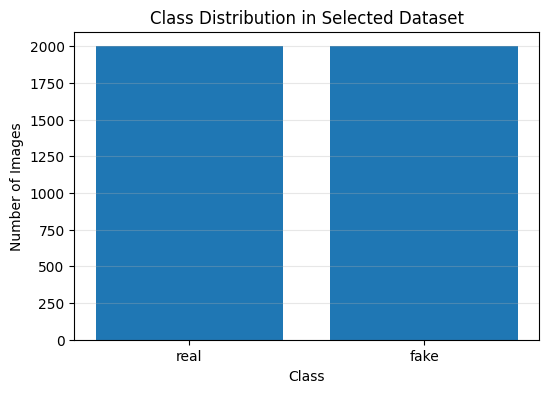

In [12]:
# ============================================================
# 10. Class Distribution Visualization
# ============================================================

class_counts = df["class_name"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution in Selected Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 7. Train/Validation/Test Split

The dataset is split into three parts:

- **Training set:** Used to train the model.
- **Validation set:** Used to tune hyperparameters and monitor overfitting.
- **Test set:** Used only for final unbiased evaluation.

A stratified split is used so that both real and fake classes remain balanced in each split.

In [13]:
# ============================================================
# 11. Train/Validation/Test Split
# ============================================================

# 60% train, 20% validation, 20% test
train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_df = shuffle(split_df, random_state=SEED).reset_index(drop=True)

print("Dataset split completed successfully.")
print("\nSplit sizes:")
print(split_df["split"].value_counts())

print("\nClass distribution by split:")
print(pd.crosstab(split_df["split"], split_df["class_name"]))

Dataset split completed successfully.

Split sizes:
split
train         2400
test           800
validation     800
Name: count, dtype: int64

Class distribution by split:
class_name  fake  real
split                 
test         400   400
train       1200  1200
validation   400   400


In [ ]:
# ============================================================
# Optional: Custom Split 2950 / 750 / 300
# ============================================================

# Uncomment this cell only if you want the exact custom split.

# train_df, temp_df = train_test_split(
#     df,
#     train_size=2950,
#     stratify=df["label"],
#     random_state=SEED
# )

# val_df, test_df = train_test_split(
#     temp_df,
#     train_size=750,
#     test_size=300,
#     stratify=temp_df["label"],
#     random_state=SEED
# )

# train_df = train_df.reset_index(drop=True)
# val_df = val_df.reset_index(drop=True)
# test_df = test_df.reset_index(drop=True)

# train_df["split"] = "train"
# val_df["split"] = "validation"
# test_df["split"] = "test"

# split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
# split_df = shuffle(split_df, random_state=SEED).reset_index(drop=True)

# print(pd.crosstab(split_df["split"], split_df["class_name"]))

# 8. Sample Image Visualization

Random samples from both classes are displayed to visually inspect the dataset.

This helps confirm that:

1. Image paths are correctly loaded.
2. Labels are assigned properly.
3. Real and AI-generated classes are visually meaningful.

# 8. Sample Image Visualization

Random samples from both classes are displayed to visually inspect the dataset.

This helps confirm that:

1. Image paths are correctly loaded.
2. Labels are assigned properly.
3. Real and AI-generated classes are visually meaningful.

# 9. Image Size Analysis

Before training deep learning models, it is important to inspect image dimensions.

Most pretrained CNN models, such as ResNet and EfficientNet, commonly use images resized to `224 × 224`.

This analysis checks the original image dimensions before resizing.

             width     height
count   200.000000   200.0000
mean   1794.800000  1712.5050
std    1549.144646  1343.6862
min     291.000000   375.0000
25%    1024.000000   934.7500
50%    1080.000000  1024.0000
75%    2004.000000  2048.0000
max    7360.000000  6240.0000


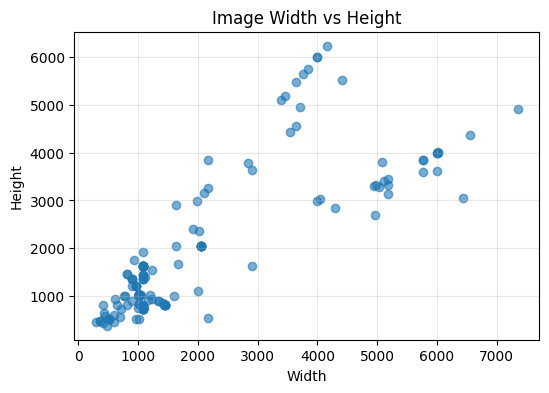

In [14]:
# ============================================================
# 13. Image Size Analysis
# ============================================================

sample_for_size = split_df.sample(n=200, random_state=SEED)

widths = []
heights = []

for path in sample_for_size["image_path"]:
    image = Image.open(path)
    widths.append(image.size[0])
    heights.append(image.size[1])

size_df = pd.DataFrame({
    "width": widths,
    "height": heights
})

print(size_df.describe())

plt.figure(figsize=(6, 4))
plt.scatter(size_df["width"], size_df["height"], alpha=0.6)
plt.title("Image Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")
plt.grid(alpha=0.3)
plt.show()

# 10. Frequency-Domain Sanity Check

AI-generated images may contain subtle artifacts that are not easily visible in the normal RGB image space.

To investigate this, images are transformed into the frequency domain using the Fast Fourier Transform.

## Why FFT?

The Fourier Transform converts an image from the spatial domain into the frequency domain.  
This allows us to inspect high-frequency and low-frequency patterns that may reveal hidden artifacts.

In this project, the FFT magnitude spectrum is used as a frequency-domain representation.

In [16]:
# ============================================================
# 14. FFT Magnitude Spectrum Function
# ============================================================

def compute_fft_magnitude(image_path, image_size=(224, 224)):
    """
    Convert an image to grayscale, resize it, compute FFT,
    shift the zero frequency component to the center,
    and return the log magnitude spectrum.
    """
    image = Image.open(image_path).convert("L")
    image = image.resize(image_size)
    
    image_array = np.array(image)
    
    fft = np.fft.fft2(image_array)
    fft_shift = np.fft.fftshift(fft)
    magnitude_spectrum = np.log1p(np.abs(fft_shift))
    
    return image, magnitude_spectrum

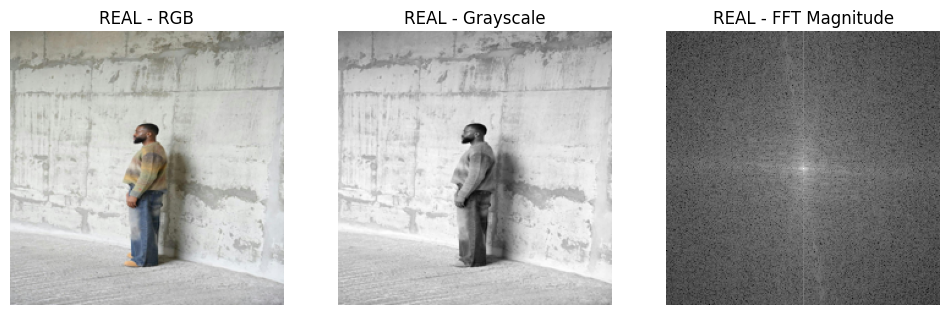

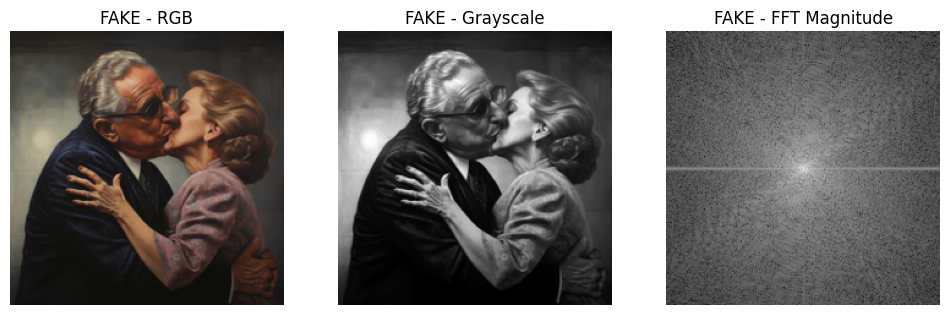

In [17]:
# ============================================================
# 15. Visual Comparison: RGB Image vs FFT Magnitude Spectrum
# ============================================================

def show_rgb_and_fft(dataframe, class_name):
    sample = dataframe[dataframe["class_name"] == class_name].sample(n=1, random_state=SEED).iloc[0]
    image_path = sample["image_path"]
    
    rgb_image = Image.open(image_path).convert("RGB").resize((224, 224))
    gray_image, fft_magnitude = compute_fft_magnitude(image_path)
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_image)
    plt.title(f"{class_name.upper()} - RGB")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(gray_image, cmap="gray")
    plt.title(f"{class_name.upper()} - Grayscale")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(fft_magnitude, cmap="gray")
    plt.title(f"{class_name.upper()} - FFT Magnitude")
    plt.axis("off")
    
    plt.show()

show_rgb_and_fft(split_df, "real")
show_rgb_and_fft(split_df, "fake")

# 11. Real vs Fake FFT Comparison

The following visualization compares multiple real and fake images with their FFT magnitude spectra.

This is a preliminary sanity check.  
It does not prove the final hypothesis by itself, but it helps visually investigate whether frequency-domain differences may exist between real and AI-generated images.

The actual conclusion will be made later using quantitative model evaluation.

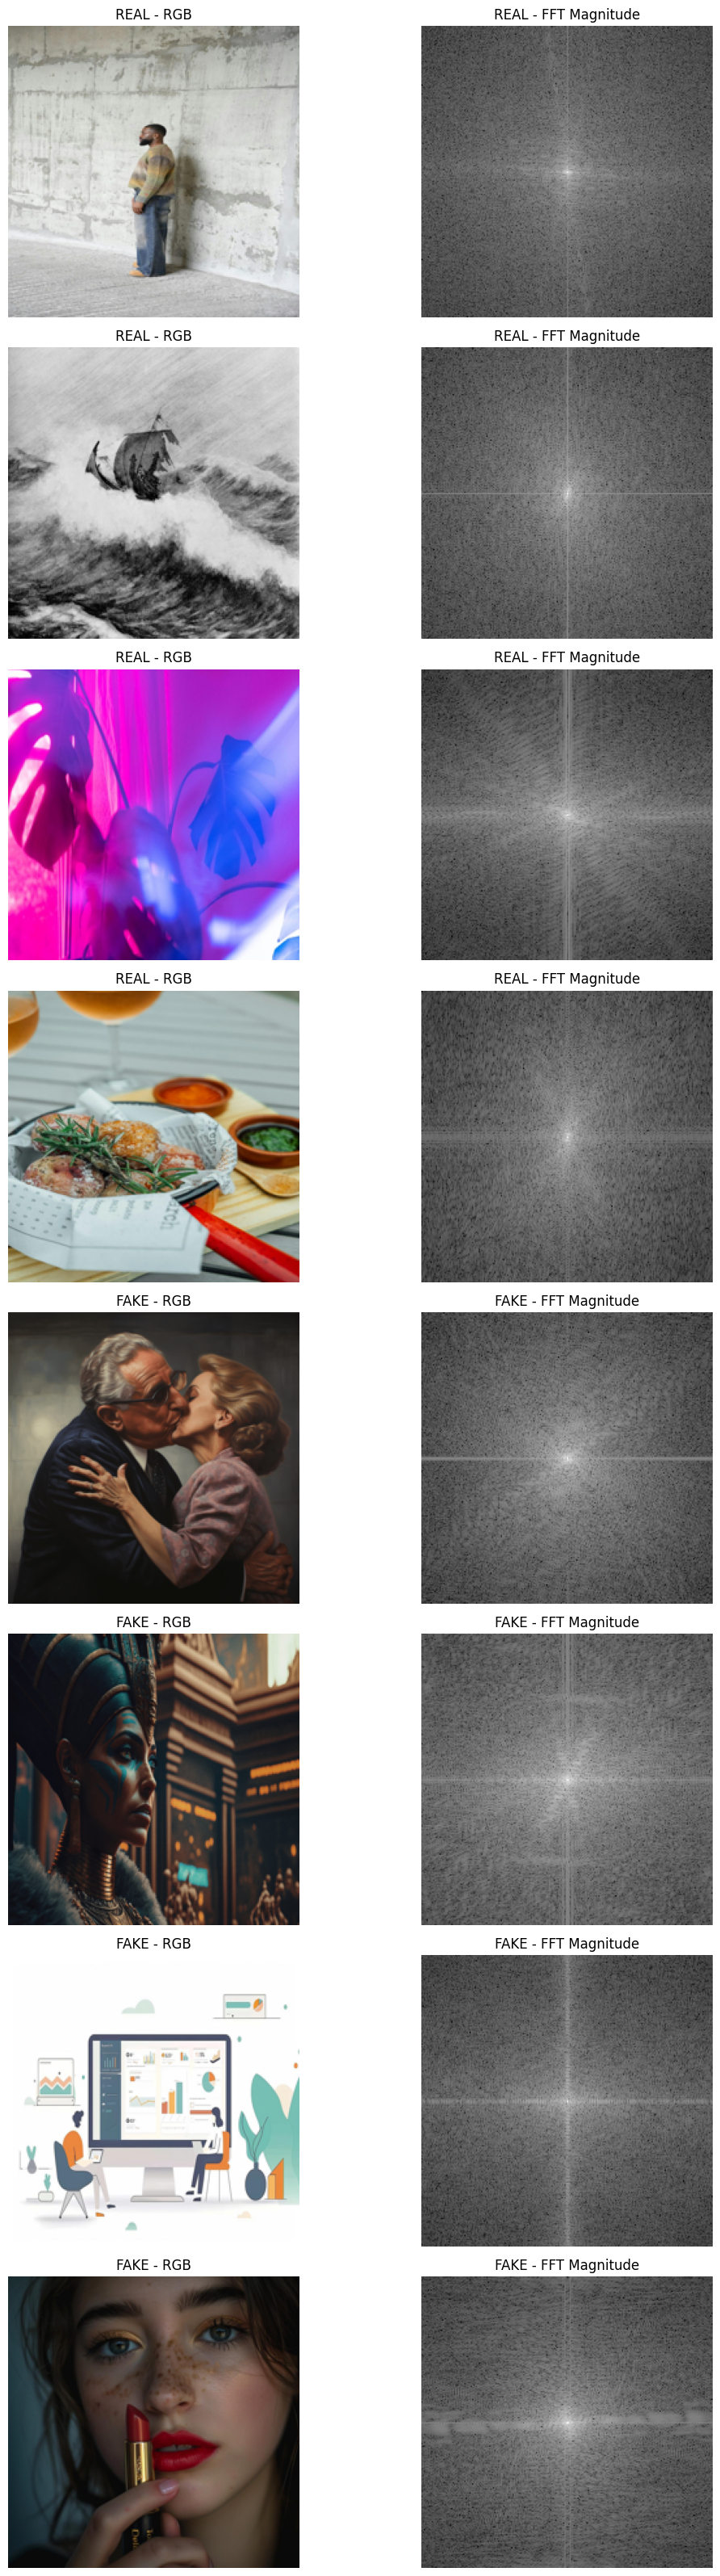

In [18]:
# ============================================================
# 16. Multiple Real vs Fake FFT Comparisons
# ============================================================

def show_multiple_fft_comparison(dataframe, n=4):
    real_samples = dataframe[dataframe["class_name"] == "real"].sample(n=n, random_state=SEED)
    fake_samples = dataframe[dataframe["class_name"] == "fake"].sample(n=n, random_state=SEED)
    
    combined = pd.concat([real_samples, fake_samples])
    
    plt.figure(figsize=(12, 4 * len(combined)))
    
    for i, (_, row) in enumerate(combined.iterrows()):
        image_path = row["image_path"]
        class_name = row["class_name"]
        
        rgb_image = Image.open(image_path).convert("RGB").resize((224, 224))
        _, fft_magnitude = compute_fft_magnitude(image_path)
        
        plt.subplot(len(combined), 2, 2*i + 1)
        plt.imshow(rgb_image)
        plt.title(f"{class_name.upper()} - RGB")
        plt.axis("off")
        
        plt.subplot(len(combined), 2, 2*i + 2)
        plt.imshow(fft_magnitude, cmap="gray")
        plt.title(f"{class_name.upper()} - FFT Magnitude")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_multiple_fft_comparison(split_df, n=4)

# 12. Save Dataset Split

The final split dataframe is saved as a CSV file.

This CSV file will be reused in future notebooks to ensure that every model is trained and evaluated on the exact same data split.

This is important for fair comparison between:

- Spatial RGB model
- Frequency-domain model
- Hybrid spatial-frequency model
- Ensemble models

In [19]:
# ============================================================
# 17. Save Split CSV
# ============================================================

output_path = "/kaggle/working/cse445_ai_image_split.csv"

split_df.to_csv(output_path, index=False)

print(f"Split CSV saved successfully at: {output_path}")
print(split_df.head())

Split CSV saved successfully at: /kaggle/working/cse445_ai_image_split.csv
                                          image_path  label class_name  \
0  /kaggle/input/datasets/tristanzhang32/ai-gener...      1       fake   
1  /kaggle/input/datasets/tristanzhang32/ai-gener...      1       fake   
2  /kaggle/input/datasets/tristanzhang32/ai-gener...      0       real   
3  /kaggle/input/datasets/tristanzhang32/ai-gener...      0       real   
4  /kaggle/input/datasets/tristanzhang32/ai-gener...      1       fake   

        split  
0       train  
1        test  
2       train  
3        test  
4  validation  


In [20]:
# ============================================================
# 18. Verify Saved CSV
# ============================================================

saved_df = pd.read_csv(output_path)

print("Saved CSV loaded successfully.")
print("Shape:", saved_df.shape)
print("\nSplit distribution:")
print(saved_df["split"].value_counts())
print("\nClass distribution by split:")
print(pd.crosstab(saved_df["split"], saved_df["class_name"]))

Saved CSV loaded successfully.
Shape: (4000, 4)

Split distribution:
split
train         2400
test           800
validation     800
Name: count, dtype: int64

Class distribution by split:
class_name  fake  real
split                 
test         400   400
train       1200  1200
validation   400   400


# 13. Phase 1 Summary

In this notebook, the dataset preparation phase was completed.

## Completed Tasks

1. Loaded and inspected the Kaggle dataset.
2. Created a balanced subset of 4000 images.
3. Selected 2000 real and 2000 AI-generated images.
4. Created a stratified train/validation/test split.
5. Visualized sample real and fake images.
6. Analyzed image dimensions.
7. Generated FFT magnitude spectra for frequency-domain inspection.
8. Saved the final split CSV for future model training.

## Final Dataset Split

| Split | Purpose |
|---|---|
| Training | Model training |
| Validation | Hyperparameter tuning and model selection |
| Testing | Final unbiased evaluation |

## Next Step

The next notebook will train a baseline spatial-domain image classifier using RGB images.

The baseline model will help establish a reference point before moving to frequency-domain and hybrid spatial-frequency models.